# Ventajas de los árboles de decisión

## 1. Lectura del dataset y creación del modelo afinado


En este ejercicio usaremos exactamente el mismo set de datos de la lección 8 (cuando construimos un árbol de regresión). Así que acá simplemente se replicará el código visto en dicha lección. De igual forma, usaremos el mismo modelo afinado obtenido en la lección anterior:

In [1]:
# Leer dataset
import pandas as pd
from sklearn.model_selection import train_test_split

RUTA = '/Users/miguel/Library/CloudStorage/GoogleDrive-miguel@codificandobits.com/My Drive/02-CODIFICANDOBITS.COM/04-Academia/01-Cursos/28-2024-10-ArbolesDeDecision/data/'
df = pd.read_csv(RUTA + 'alquiler_apartamentos.csv')

# Convertir la variable "price-display" a su representación numérica
df = df[~df['price_display'].str.contains('-')]
df['price'] = df['price_display'].replace({'\$': '', ',': ''}, regex=True).astype(float)

# Eliminar columnas irrelevantes
df.drop(columns=['title', 'body', 'price_display', 'category'], inplace=True)

# Codificación "one-hot" de las variables categóricas
df = pd.get_dummies(df)

# Reordenamiento de las columnas (para dejar "price" como última columna)
df = df[['bathrooms', 'bedrooms', 'square_feet', 'fee_No', 'fee_Yes',
       'pets_allowed_Cats', 'pets_allowed_Cats,Dogs', 'pets_allowed_Dogs',
       'pets_allowed_None', 'price']]

# Arreglos x y y
x = df.iloc[:,:-1]
y = df.iloc[:,-1]

# Creación sets de entrenamiento/validación y prueba
x_tr, x_ts, y_tr, y_ts = train_test_split(x, y, 
                                          test_size=0.25, # Tamaño del set de prueba: 25% del total 
                                          random_state=123, # Para reproducibilidad
                                          )

Y a continuación entrenamos el árbol con el mejor set de hiper-parámetros obtenido en la lección anterior:

{'criterion': 'squared_error',
 'max_depth': 5,
 'max_leaf_nodes': 100,
 'min_samples_split': 5}

In [2]:
# Entrenamiento básico del regresor
from sklearn.tree import DecisionTreeRegressor

# Crear instancia del clasificador AFINADO y entrenar con el set de entrenamiento/validación (x_trvl, y_trvl)
arbol = DecisionTreeRegressor(criterion='squared_error',
                              max_depth=5,
                              max_leaf_nodes=100,
                              min_samples_split=5,
                              random_state=123)
arbol.fit(x_tr, y_tr)

DecisionTreeRegressor(max_depth=5, max_leaf_nodes=100, min_samples_split=5,
                      random_state=123)

## 2. Ventajas de los árboles de decisión

### 2.1. Ventaja 1: interpretabilidad

Tras construir un árbol podemos visualizarlo y determinar fácilmente la secuencia de pasos que permiten generar una predicción en particular:

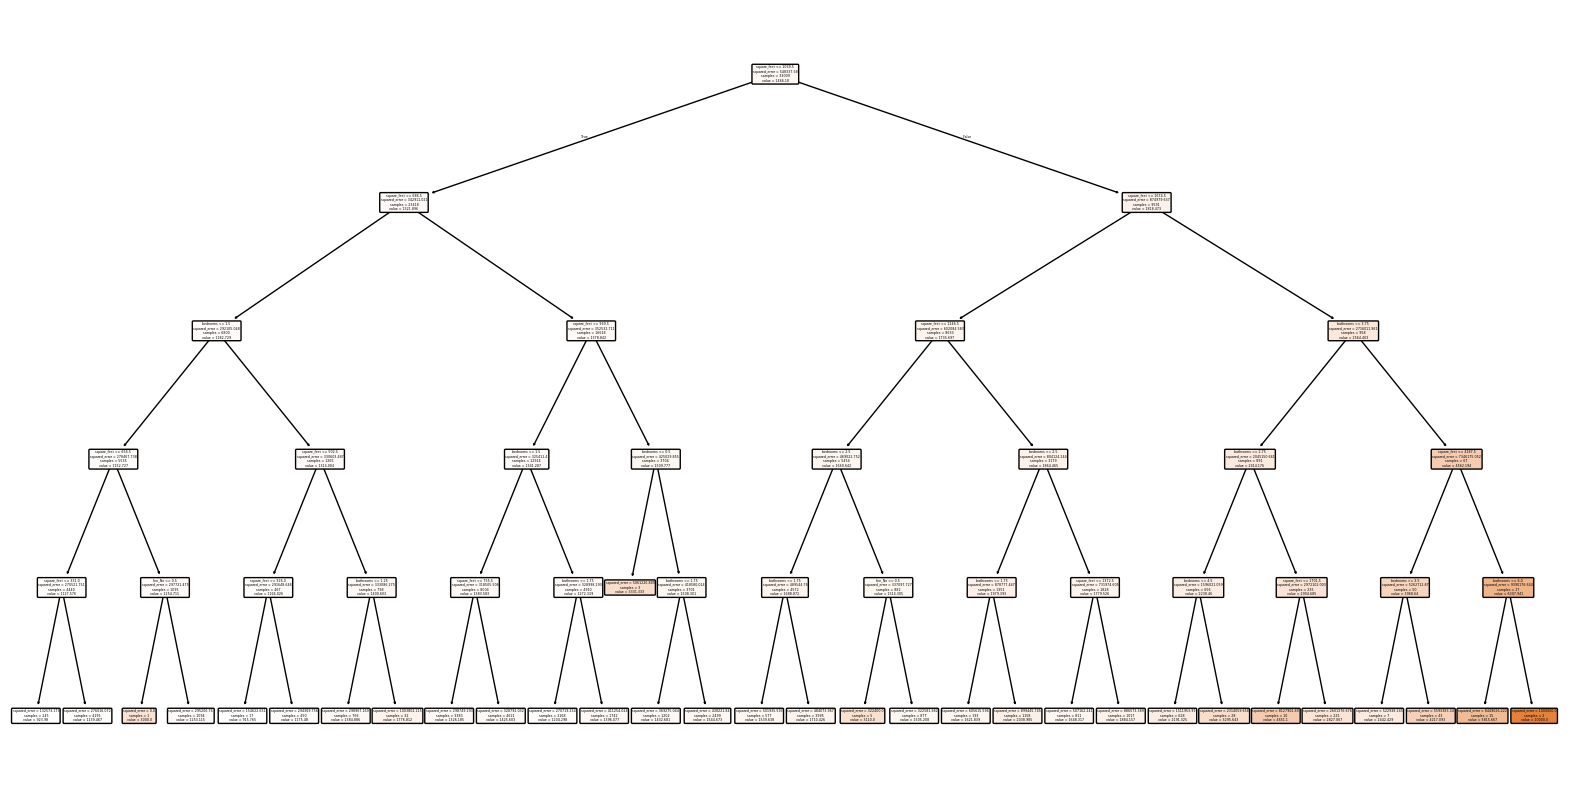

In [3]:
# Visualización del árbol
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))  # Tamaño de la figura
tree.plot_tree(arbol,
               feature_names=x_tr.columns, # Para que contenga los nombres de las características
               class_names = [y_tr.name], # Para que contenga los nombres de las categorías
               filled=True,  # Colorear las hojas
               rounded=True, # Bordes redondeados
               );
plt.savefig('arbol_regresion_afinado.png', dpi=300)

Además, en un árbol de decisión podemos calcular algo que se conoce como la **importancia de las características** que permite generar un "ranking" de las características más relevantes a las menos relevantes.

Esencialmente lo que se hace es calcular qué tanto logra cada característica reducir la impureza (Gini, Entropía, error cuadrático medio, etc.) de los nodos. Aquellas características que logren reducir más la impureza serán más importantes que aquellas que logren reducciones menores.

En Scikit-Learn este importancia de las características es calculada en el mismo momento en que se entrena el árbol, y están disponibles en el atributo "feature_importances_":

In [4]:
arbol.feature_importances_

array([0.1414459 , 0.05133183, 0.80269184, 0.00453044, 0.        ,
       0.        , 0.        , 0.        , 0.        ])

Estas son las importancias asociadas a cada característica y para facilitar su comprensión podemos ponerlas en una Serie de Pandas junto con su nombre correspondiente:

In [5]:
x_tr

,bathrooms,bedrooms,square_feet,fee_No,fee_Yes,pets_allowed_Cats,"pets_allowed_Cats,Dogs",pets_allowed_Dogs,pets_allowed_None
18972,1.0,1.0,719,1,0,0,1,0,0
34689,2.0,2.0,1060,1,0,0,1,0,0
32575,2.0,3.0,1620,1,0,0,1,0,0
31918,2.0,2.0,1015,1,0,0,1,0,0
34508,2.0,3.0,1155,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...
7763,1.0,2.0,573,1,0,0,1,0,0
15377,1.0,1.0,760,1,0,0,1,0,0
17730,2.0,2.0,1058,1,0,0,1,0,0
28054,1.0,1.0,611,1,0,0,1,0,0


In [6]:
import pandas as pd

importancias = pd.Series(arbol.feature_importances_, index=x_tr.columns).sort_values(ascending=False)
importancias

square_feet               0.802692
bathrooms                 0.141446
bedrooms                  0.051332
fee_No                    0.004530
fee_Yes                   0.000000
pets_allowed_Cats         0.000000
pets_allowed_Cats,Dogs    0.000000
pets_allowed_Dogs         0.000000
pets_allowed_None         0.000000
dtype: float64

E incluso podemos graficarlas:

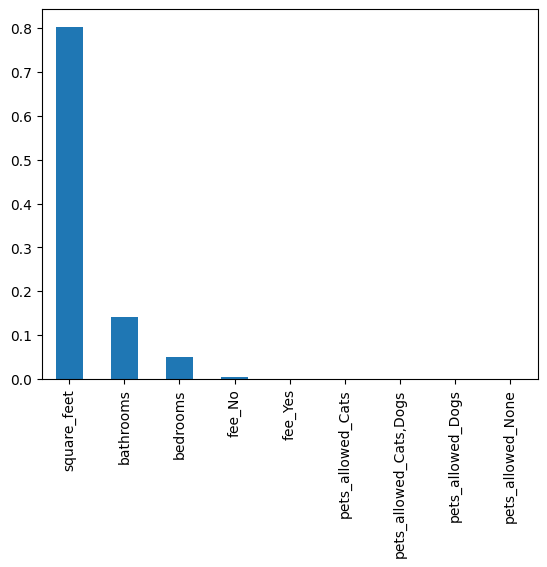

In [8]:
importancias.plot.bar();

Y vemos que por ejemplo en este caso particular la variable "square_feet" (el área del inmueble) es la más relevante al momento de generar las predicciones.

Así que estas importancias de las características son otra herramienta que nos permite explicar cómo el árbol genera predicciones, pues nos permite determinar cuáles son las características más relevantes al momento de generar una predicción.

### 2.2. Ventaja 2: no es necesario escalar los datos

En modelos como las Redes Neuronales o incluso la regresión lineal o la regresión logística, generalmente las diferentes variables se deben llevar a una misma escala para evitar que el modelo entrenado tenga un sesgo hacia una u otra variable.

La ventaja de usar árboles de decisión es que **no es necesario escalar los datos**. Esto se debe en esencia a que el algoritmo CART calcula los diferentes umbrales **analizando cada variable de manera individual**, así que cada variable puede tener una escala diferente y esto no representará un problema para el algoritmo:

In [9]:
df

,bathrooms,bedrooms,square_feet,fee_No,fee_Yes,pets_allowed_Cats,"pets_allowed_Cats,Dogs",pets_allowed_Dogs,pets_allowed_None,price
0,1.0,1.0,542,1,0,1,0,0,0,2195.0
1,1.5,3.0,1500,1,0,0,1,0,0,1250.0
2,2.0,3.0,1650,1,0,0,0,0,1,1395.0
3,1.0,2.0,820,1,0,0,1,0,0,1600.0
4,1.0,1.0,624,1,0,0,1,0,0,975.0
...,...,...,...,...,...,...,...,...,...,...
44036,1.0,1.0,625,1,0,0,1,0,0,685.0
44037,1.0,1.0,650,1,0,0,1,0,0,798.0
44038,2.0,2.0,921,1,0,0,1,0,0,813.0
44039,1.0,1.0,650,1,0,0,1,0,0,1325.0


### 2.3. Otras ventajas

- Los árboles de decisión pueden aceptar variables tanto numéricas como categóricas
- Los árboles de decisión pueden ser entrenados con datos faltantes. Por ejemplo, si una celda de una característica en particular está incompleta simplemente no será tenida en cuenta por el algoritmo CART al momento de generar las particiones.